### Imports

In [ ]:
from csdp_training.experiments.bids_predictor import USleep_Predictor
from csdp_pipeline.plot_hypnogram import plotHypnoGram
import matplotlib.pyplot as plt

### Exploring the file
First, we initialize the predictor class, choose a model checkpoint, and then we point the predictor to our MNE compatible file\
With the function "get_available_channels" we can explore the available channels in the file

In [2]:
# Path to the weights that should be used - both the Pretrained and the Generalized model are in the repository 
checkpoint = "weights/Pretrained_Model.ckpt"

# Path to the .set, .vhdr or .edf file
filepath = ""

predictor = USleep_Predictor(filepath=filepath)

# Peek the data and obtain avaiable channels
ch_names = predictor.get_available_channels()
print(ch_names)

{'F4', 'ELA', 'ELI', 'ERC', 'F3', 'C4', 'M1', 'EOGl', 'ERE', 'ERI', 'EMGr', 'ELE', 'EMGl', 'ELT', 'O1', 'EOGr', 'EMGc', 'ELC', 'ELB', 'O2', 'ERB', 'C3', 'ERT', 'M2', 'ERA'}


### Predicting
Now that we know the available channels, it is time to predict\
Use the function "build_dataset" and list the channels that you want to utilize\
Finally use the function "predict_all" and indicate which of the aforementioned channels should be used as EEG and EOG

In [3]:
# Choose which channels to use for building the dataset object
dataset = predictor.build_dataset(["F3", "C3", "EOGl", "EOGr"])

# Predict on all the data. We tell U-Sleep which of the above channel indexes are EEG and EOG
prediction, confidences = predictor.predict_all(checkpoint, dataset, eeg_indexes=[0,1], eog_indexes=[2,3])
print(prediction)

[tensor([0, 0, 0,  ..., 0, 0, 0])]


### Plotting the hypnogram

In [5]:
prediction = prediction[0].numpy()

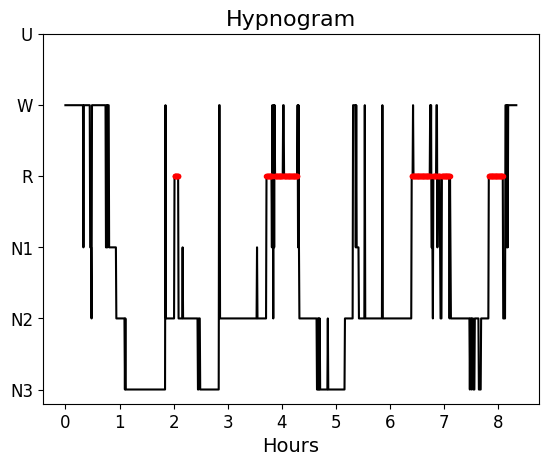

In [6]:
fig, (ax) = plt.subplots(1,1)
plotHypnoGram(prediction, ax)